Задание
1. Из ноутбуков по практике "Рекуррентные и одномерные сверточные нейронные сети" выберите лучшую сеть, либо создайте свою.
2. Запустите раздел "Подготовка"
3. Подготовьте датасет с параметрами `VOCAB_SIZE=20'000`, `WIN_SIZE=1000`, `WIN_HOP=100`, как в ноутбуке занятия, и обучите выбранную сеть. Параметры обучения можно взять из практического занятия. Для  всех обучаемых сетей в данной работе они должны быть одни и теже.
4. Поменяйте размер словаря tokenaizera (`VOCAB_SIZE`) на `5000`, `10000`, `40000`.  Пересоздайте датасеты, при этом оставьте `WIN_SIZE=1000`, `WIN_HOP=100`.
Обучите выбранную нейронку на этих датасетах.  Сделайте выводы об  изменении  точности распознавания авторов текстов. Результаты сведите в таблицу
5. Поменяйте длину отрезка текста и шаг окна разбиения текста на векторы  (`WIN_SIZE`, `WIN_HOP`) используя значения (`500`,`50`) и (`2000`,`200`). Пересоздайте датасеты, при этом оставьте `VOCAB_SIZE=20000`. Обучите выбранную нейронку на этих датасетах. Сделайте выводы об  изменении точности распознавания авторов текстов.

Результаты всей работы сведите в таблицу.


# **Импорты**

In [1]:
import os
import re
import time

import gdown
import matplotlib.pyplot as plt
import numpy as np

from IPython.display import display
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

from tensorflow.keras import utils
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Activation,
    BatchNormalization,
    Bidirectional,
    Conv1D,
    Dense,
    Dropout,
    Embedding,
    Flatten,
    GlobalMaxPooling1D,
    GRU,
    LSTM,
    MaxPooling1D,
    SimpleRNN,
    SpatialDropout1D,
)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.utils import plot_model

%matplotlib inline


# **Загрузка данных**

In [2]:
# Скачивание и распаковка архива с текстами писателей
DATA_URL = 'https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip'
ARCHIVE_NAME = 'writers.zip'
DATA_FOLDER = 'writers'

gdown.download(DATA_URL, ARCHIVE_NAME, quiet=True)
!unzip -o writers.zip -d writers/


Archive:  writers.zip
  inflating: writers/(Клиффорд_Саймак) Обучающая_5 вместе.txt  
  inflating: writers/(Клиффорд_Саймак) Тестовая_2 вместе.txt  
  inflating: writers/(Макс Фрай) Обучающая_5 вместе.txt  
  inflating: writers/(Макс Фрай) Тестовая_2 вместе.txt  
  inflating: writers/(О. Генри) Обучающая_50 вместе.txt  
  inflating: writers/(О. Генри) Тестовая_20 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Обучающая_22 вместе.txt  
  inflating: writers/(Рэй Брэдберри) Тестовая_8 вместе.txt  
  inflating: writers/(Стругацкие) Обучающая_5 вместе.txt  
  inflating: writers/(Стругацкие) Тестовая_2 вместе.txt  
  inflating: writers/(Булгаков) Обучающая_5 вместе.txt  
  inflating: writers/(Булгаков) Тестовая_2 вместе.txt  


# **Пути до файлов**

In [3]:
# Основные настройки для чтения файлов датасета
FILE_DIR = 'writers'
SIG_TRAIN = 'обучающая'
SIG_TEST = 'тестовая'


# **Подготовка списков и добавление текстов**

In [4]:
# Списки с названиями классов и текстами для обучения/проверки
CLASS_LIST = []
text_train = []
text_test = []

# Перебираем все файлы в папке датасета
for file_name in os.listdir(FILE_DIR):
    match = re.match(r'\((.+)\) (\S+)_', file_name)

    if match is None:
        continue

    class_name = match.group(1)
    subset_name = match.group(2).lower()

    is_train_file = SIG_TRAIN in subset_name
    is_test_file = SIG_TEST in subset_name

    if not (is_train_file or is_test_file):
        continue

    if class_name not in CLASS_LIST:
        CLASS_LIST.append(class_name)
        text_train.append('')
        text_test.append('')
        print(f'Добавление класса "{class_name}"')

    class_index = CLASS_LIST.index(class_name)
    print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[class_index]}", {subset_name} выборка.')

    file_path = os.path.join(FILE_DIR, file_name)
    with open(file_path, 'r') as file:
        file_text = file.read().replace('\n', ' ')

    target_collection = text_train if is_train_file else text_test
    target_collection[class_index] += ' ' + file_text


Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Обучающая_5 вместе.txt" в класс "Макс Фрай", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгаков) Обучающая_5 вместе.txt" в класс "Булгаков", обучающая выборка.
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Тесто

# **Определение количества классов и вывод текстов**

In [5]:
# Количество классов определяется после загрузки текстов
CLASS_COUNT = len(CLASS_LIST)

print(CLASS_LIST)
print(len(text_train))

# Контрольный вывод показываем первые символы каждого класса
for class_index, class_name in enumerate(CLASS_LIST):
    print(f'Класс: {class_name}')
    print(f'  train: {text_train[class_index][:200]}')
    print(f'  test : {text_test[class_index][:200]}')
    print()


['Клиффорд_Саймак', 'О. Генри', 'Рэй Брэдберри', 'Макс Фрай', 'Булгаков', 'Стругацкие']
6
Класс: Клиффорд_Саймак
  train:  ﻿Всё живое...     Когда я выехал из нашего городишка и повернул на шоссе, позади оказался грузовик. Этакая тяжелая громадина с прицепом, и неслась она во весь дух. Шоссе здесь срезает угол городка, и
  test :  ﻿Зачарованное паломничество    1  Гоблин со стропил следил за прячущимся монахом, который шпионил за ученым. Гоблин ненавидел монаха и имел для этого все основания. Монах никого не ненавидел и не люб

Класс: О. Генри
  train:  «Лиса-на-рассвете»   Коралио нежился в полуденном зное, как томная красавица в сурово хранимом гареме. Город лежал у самого моря на полоске наносной земли. Он казался брильянтиком, вкрапленным в ярко
  test :  ﻿Багдадская птица   Без всякого сомнения, дух и гений калифа Гаруна аль-Рашида осенил маркграфа Августа-Михаила фон Паульсена Квигга.  Ресторан Квигга находится на Четвертой авеню — на улице, которую

Класс: Рэй Брэдберри
  train:

# **Контекстный менеджер**

In [6]:
# Небольшой менеджер для замера времени выполнения блока кода
class timex:
    def __enter__(self):
        self.start_time = time.time()
        return self

    def __exit__(self, exc_type, exc_value, traceback):
        elapsed_time = time.time() - self.start_time
        print('Время обработки: {:.2f} с'.format(elapsed_time))


# **Разбиение текста**

In [7]:
# Нарезка последовательностей на окна фиксированной длины
def get_samples(texts, win_size, win_hop):
    samples = []
    labels = []

    for class_index, token_sequence in enumerate(texts):
        last_start = len(token_sequence) - win_size + 1

        for start in range(0, last_start, win_hop):
            end = start + win_size
            samples.append(token_sequence[start:end])
            labels.append(utils.to_categorical(class_index, CLASS_COUNT))

    return np.array(samples), np.array(labels)


# **Написание функций**

In [8]:
# Функция вывода графиков обучения. Она должна быть объявлена до запуска экспериментов.
def plot_training_history(history):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history.history['accuracy'], label='Обучающая выборка')
    axes[0].plot(history.history['val_accuracy'], label='Проверочная выборка')
    axes[0].set_title('График точности')
    axes[0].set_xlabel('Эпоха')
    axes[0].set_ylabel('Точность')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history.history['loss'], label='Обучающая выборка')
    axes[1].plot(history.history['val_loss'], label='Проверочная выборка')
    axes[1].set_title('График ошибки')
    axes[1].set_xlabel('Эпоха')
    axes[1].set_ylabel('Ошибка')
    axes[1].legend()
    axes[1].grid(True)

    plt.show()


# Универсальная функция одного эксперимента с заданными параметрами выборки
def run_experiment(vocab_size, win_size, win_hop, epochs=20):
    tokenizer = Tokenizer(
        num_words=vocab_size,
        filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n',
        lower=True,
        split=' ',
        char_level=False,
    )
    tokenizer.fit_on_texts(text_train)

    train_sequences = tokenizer.texts_to_sequences(text_train)
    test_sequences = tokenizer.texts_to_sequences(text_test)

    x_train, y_train = get_samples(train_sequences, win_size, win_hop)
    x_test, y_test = get_samples(test_sequences, win_size, win_hop)

    model = Sequential([
        Embedding(vocab_size, 50, input_length=win_size),
        SpatialDropout1D(0.2),
        BatchNormalization(),
        Conv1D(20, 5, activation='relu'),
        MaxPooling1D(2),
        Dropout(0.2),
        Flatten(),
        Dense(CLASS_COUNT, activation='softmax'),
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy'],
    )

    with timex():
        history = model.fit(
            x_train,
            y_train,
            epochs=epochs,
            batch_size=128,
            validation_data=(x_test, y_test),
            verbose=0,
        )

    plot_training_history(history)
    return max(history.history['val_accuracy'])


# **Проведение первого эксперимента**


Тестирование VOCAB_SIZE = 5000...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Время обработки: 44.10 с


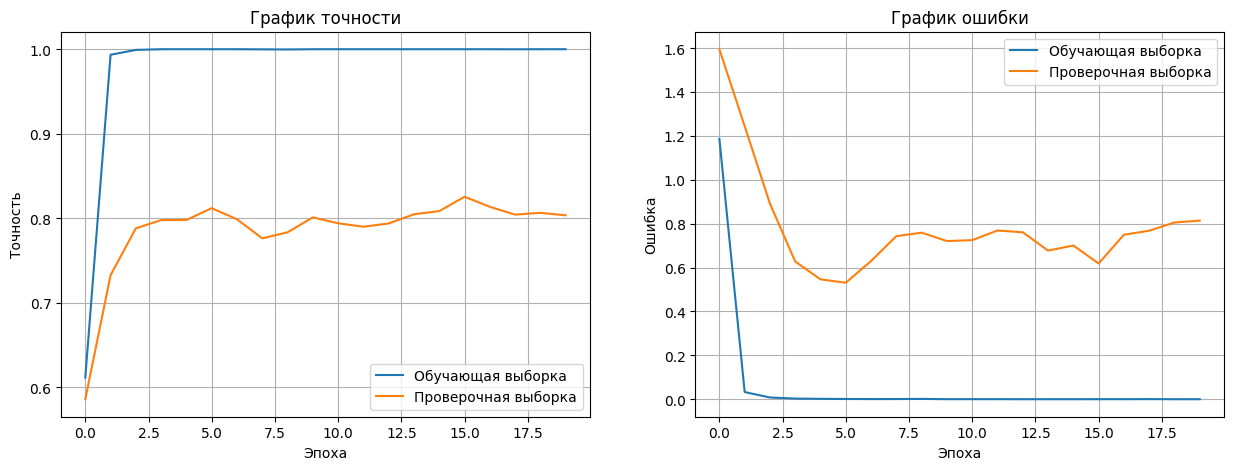


Тестирование VOCAB_SIZE = 10000...
Время обработки: 43.73 с


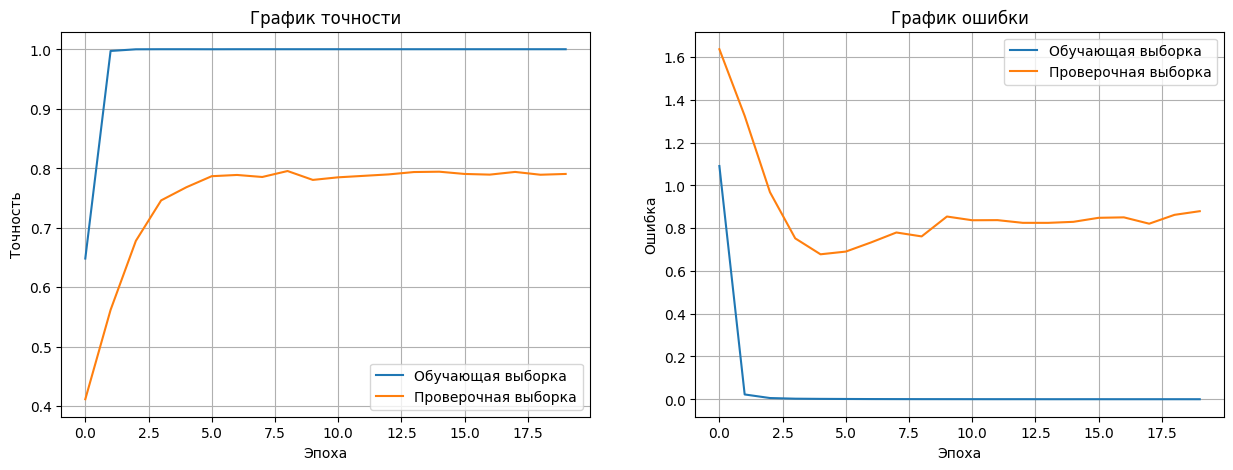


Тестирование VOCAB_SIZE = 20000...
Время обработки: 47.54 с


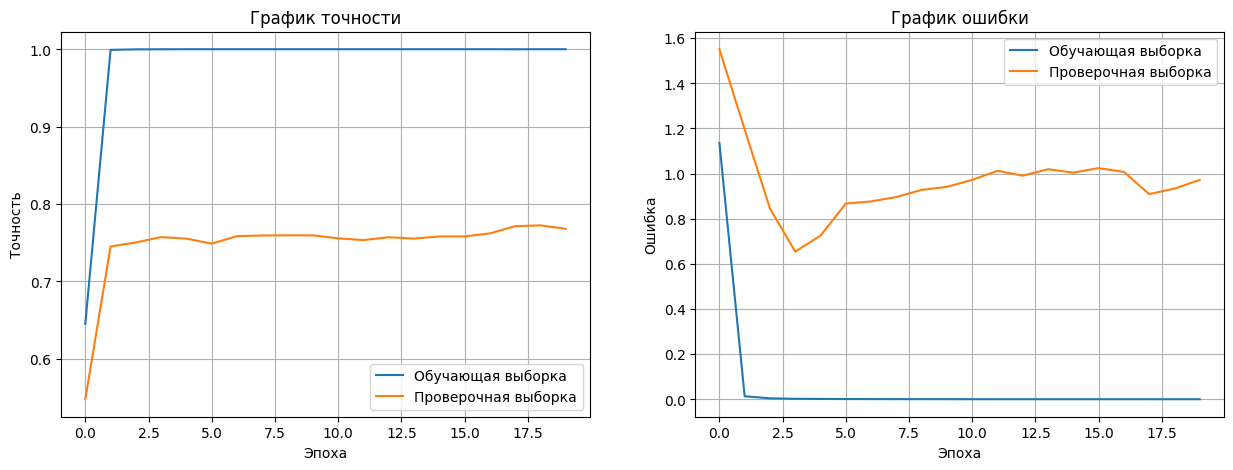


Тестирование VOCAB_SIZE = 40000...
Время обработки: 50.57 с


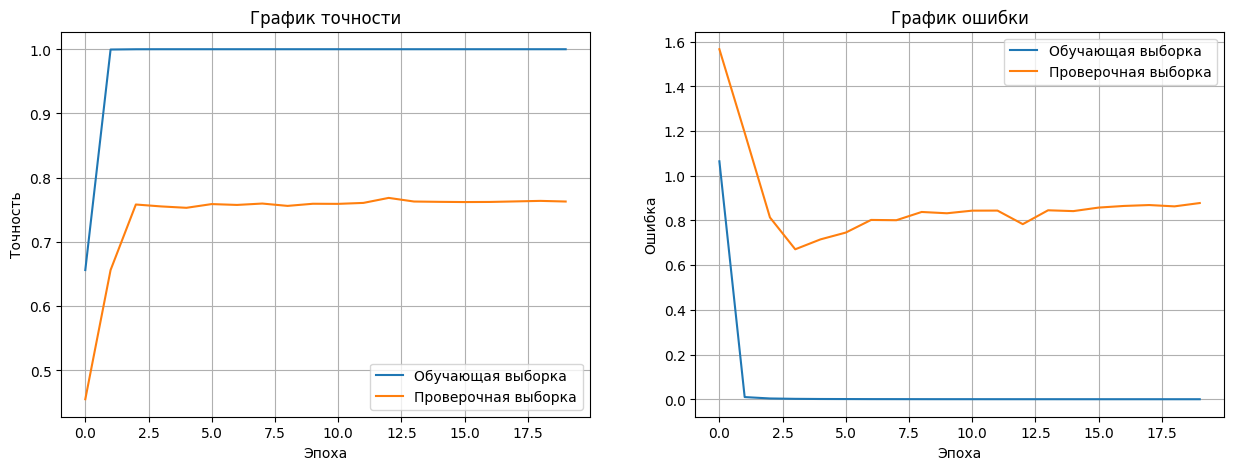

In [9]:
results = []

# Проверяем влияние размера словаря при фиксированных параметрах окна
for vocab_size in [5000, 10000, 20000, 40000]:
    print(f'\nТестирование VOCAB_SIZE = {vocab_size}...')

    best_accuracy = run_experiment(
        vocab_size=vocab_size,
        win_size=1000,
        win_hop=100,
    )

    results.append({
        'VOCAB_SIZE': vocab_size,
        'WIN_SIZE': 1000,
        'WIN_HOP': 100,
        'Accuracy': best_accuracy,
    })


# **Проведение второго эксперимента**


Тестирование WIN_SIZE = 500, WIN_HOP = 50...
Время обработки: 55.36 с


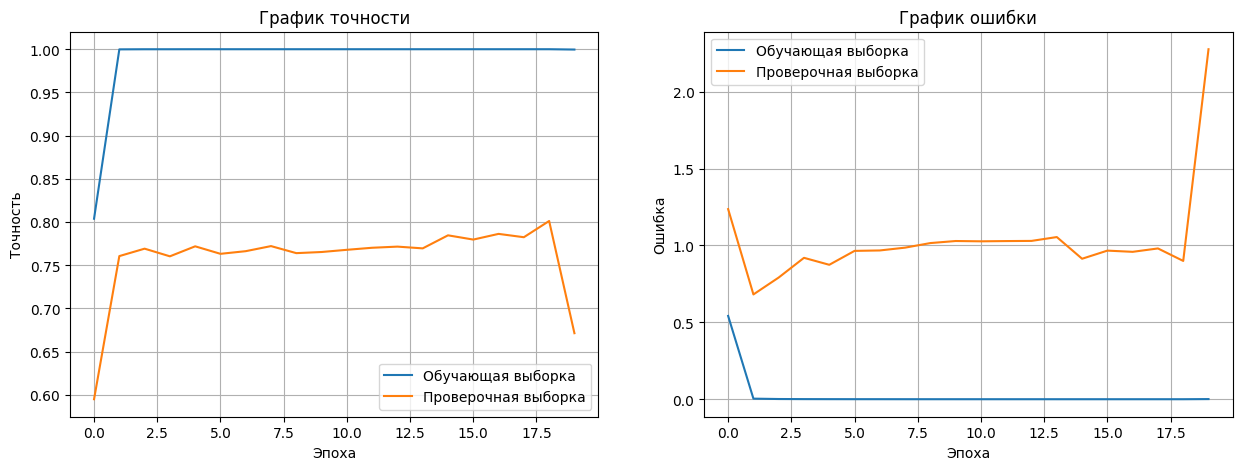


Тестирование WIN_SIZE = 2000, WIN_HOP = 200...
Время обработки: 45.18 с


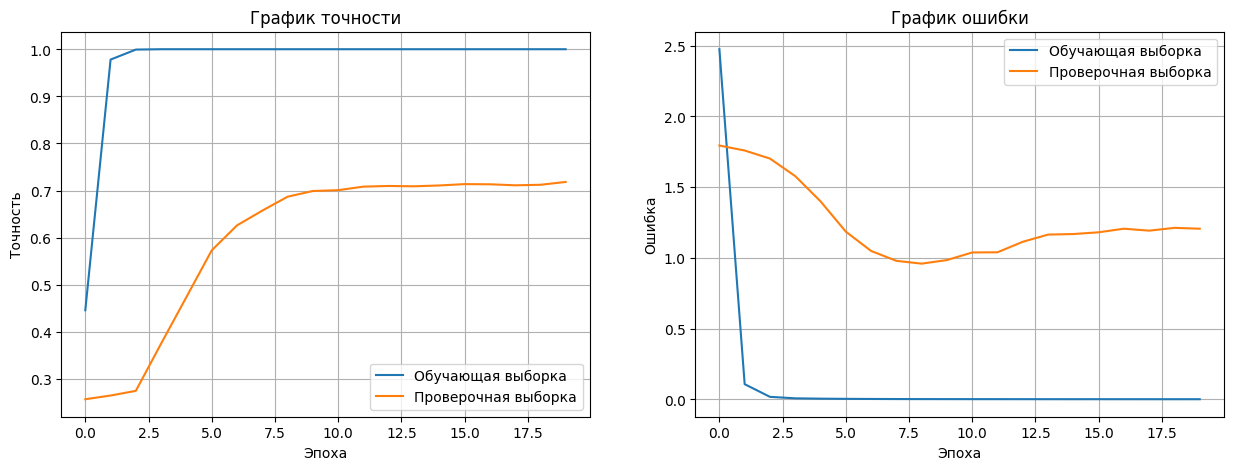

In [10]:
# Проверяем влияние размера окна и шага при фиксированном размере словаря
for win_size, win_hop in [(500, 50), (2000, 200)]:
    print(f'\nТестирование WIN_SIZE = {win_size}, WIN_HOP = {win_hop}...')

    best_accuracy = run_experiment(
        vocab_size=20000,
        win_size=win_size,
        win_hop=win_hop,
    )

    results.append({
        'VOCAB_SIZE': 20000,
        'WIN_SIZE': win_size,
        'WIN_HOP': win_hop,
        'Accuracy': best_accuracy,
    })


# **Сводная таблица**

In [11]:
# Итоговый вывод результатов всех запусков
header = '{:<12} | {:<10} | {:<10} | {:<10}'.format('VOCAB_SIZE', 'WIN_SIZE', 'WIN_HOP', 'Accuracy')
print('\n' + header)
print('-' * 50)

for row in results:
    print('{:<12} | {:<10} | {:<10} | {:<10.4f}'.format(
        row['VOCAB_SIZE'],
        row['WIN_SIZE'],
        row['WIN_HOP'],
        row['Accuracy'],
    ))



VOCAB_SIZE   | WIN_SIZE   | WIN_HOP    | Accuracy  
--------------------------------------------------
5000         | 1000       | 100        | 0.8255    
10000        | 1000       | 100        | 0.7952    
20000        | 1000       | 100        | 0.7722    
40000        | 1000       | 100        | 0.7684    
20000        | 500        | 50         | 0.8012    
20000        | 2000       | 200        | 0.7183    
